# Tutorial Part 2 --- Model Selection & Cross-Validation

Training-set metrics lie. A model can appear fair on training data but be unfair on new data --- especially with flexible kernel methods that can memorize group structure. A kernel matrix with 200 samples has 200 degrees of freedom; it can easily absorb the sensitive signal *and* look like it hasn't. Cross-validation is the standard antidote.

This tutorial builds a rigorous model-selection pipeline for Fair Kernel Ridge Regression, progressing from standard hyperparameters ($\sigma$, $\lambda$) to the fairness penalty $\mu$.

**Table of contents**

1. Why Cross-Validate?
2. The sklearn Bridge
3. Tuning the Standard Model ($\mu = 0$)
4. Fairness-Aware Cross-Validation
5. Results: Cross-Validated Pareto Frontier

In [1]:
from __future__ import annotations

import os

os.environ["KERAS_BACKEND"] = "jax"

import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import KFold, cross_val_score

from fairkl.metrics.cka import cka_rbf
from fairkl.models import FairKernelRidge
from fairkl.sklearn_compat import FairKRREstimator
from _style import style_ax

---
## Why Cross-Validate?

Cross-validation estimates how a model will perform on *unseen* data. The standard $K$-fold estimator partitions the data into $K$ non-overlapping folds and averages the held-out loss:

$$\text{CV}(f) = \frac{1}{K}\sum_{k=1}^{K} \mathcal{L}\!\bigl(f_{-k},\; \mathcal{D}_k\bigr)$$

where $f_{-k}$ is the model trained on all folds *except* the $k$-th, and $\mathcal{D}_k$ is the held-out fold. This is especially important for kernel methods: the kernel matrix $K \in \mathbb{R}^{n \times n}$ is a rich enough basis that the model can interpolate the training data perfectly when $\lambda$ is small. Training-set MSE will look great while the model generalizes poorly.

### Train-set fairness $\neq$ test-set fairness

Fairness adds a second dimension to overfitting. A large enough kernel matrix can learn to *hide* the sensitive signal in the training predictions --- CKA drops to near zero on the training set --- while the learned function still encodes group structure that reappears on new data. The only way to detect this is to evaluate fairness on held-out data.

---
## The sklearn Bridge

### FairKRREstimator: wrapping Keras for sklearn

Keras 3 ships `keras.wrappers.SKLearnRegressor`, but it wraps models that use `model.compile()` + `model.fit(x, y, epochs=...)`. `FairKernelRidge` has a custom solver (Cholesky for $\mu=0$, Adam for $\mu>0$), so we need a purpose-built adapter.

`fairkl.sklearn_compat.FairKRREstimator` is that adapter.  It inherits from `BaseEstimator` + `RegressorMixin` and delegates `fit` / `predict` to a fresh `FairKernelRidge` instance.

### `get_params`, `set_params`, and the sklearn contract

**Engineering trick: sklearn contract.** `BaseEstimator` provides `get_params()` / `set_params()` for free as long as every `__init__` argument is stored as an attribute with the *same name*. `RegressorMixin` adds `.score()` which defaults to $R^2$. This contract is what makes `cross_val_score` and `GridSearchCV` work --- they call `set_params` to inject hyperparameters, then `fit` + `score` on each fold.

## Same Synthetic Data as Part 1

$y = \sin(x) + 3q + \varepsilon$, so the target is strongly coupled to the sensitive attribute $q$.

In [2]:
rng = np.random.default_rng(0)
n = 200
x = rng.standard_normal((n, 1)).astype("float32")
q = rng.standard_normal((n, 1)).astype("float32")
X = np.hstack([x, q]).astype("float32")
y = (np.sin(x.ravel()) + 3.0 * q.ravel() + 0.3 * rng.standard_normal(n)).astype(
    "float32"
)
print(
    f"n = {n},  d = {X.shape[1]},  corr(y, q) = {np.corrcoef(y, q.ravel())[0, 1]:.3f}"
)

n = 200,  d = 2,  corr(y, q) = 0.972


Quick sanity check that the wrapper works:

In [3]:
est = FairKRREstimator(sigma=1.0, lam=0.01, mu=0.0)
print("get_params:", est.get_params())
est.fit(X, y)
print(f"R^2 = {est.score(X, y):.3f}")

get_params: {'epochs': 200, 'kernel': 'rbf', 'lam': 0.01, 'lr': 0.005, 'mu': 0.0, 'sigma': 1.0, 'sigma_q': 1.0}


R^2 = 0.992


---
## Tuning the Standard Model ($\mu = 0$)

With $\mu = 0$ the model reduces to standard kernel ridge regression. There is no sensitive-attribute penalty, so sklearn's `cross_val_score` works directly. We tune two hyperparameters: the RBF bandwidth $\sigma$ and the ridge parameter $\lambda$.

### Bandwidth selection via CV

The RBF kernel $K_{ij} = \exp(-\|x_i - x_j\|^2 / 2\sigma^2)$ has a classic bias--variance trade-off controlled by $\sigma$:

| $\sigma$ | Kernel behavior | Bias | Variance |
|----------|----------------|------|----------|
| Small | Each point is its own island --- interpolation | Low | High |
| Large | All points look similar --- underfitting | High | Low |

The sweet spot minimizes the CV-MSE curve.

In [4]:
sigmas = [0.1, 0.3, 0.5, 1.0, 2.0, 3.0, 5.0]
cv_scores_sigma = []
cv_stds_sigma = []

for s in sigmas:
    est = FairKRREstimator(sigma=s, lam=0.01, mu=0.0)
    scores = cross_val_score(est, X, y, cv=5, scoring="neg_mean_squared_error")
    cv_scores_sigma.append(-scores.mean())
    cv_stds_sigma.append(scores.std())
    print(f"sigma = {s:4.1f}   CV-MSE = {-scores.mean():.3f} +/- {scores.std():.3f}")

sigma =  0.1   CV-MSE = 6.789 +/- 2.588
sigma =  0.3   CV-MSE = 3.408 +/- 2.494
sigma =  0.5   CV-MSE = 2.555 +/- 2.302
sigma =  1.0   CV-MSE = 0.890 +/- 1.159
sigma =  2.0   CV-MSE = 0.181 +/- 0.151
sigma =  3.0   CV-MSE = 0.115 +/- 0.042
sigma =  5.0   CV-MSE = 0.141 +/- 0.056


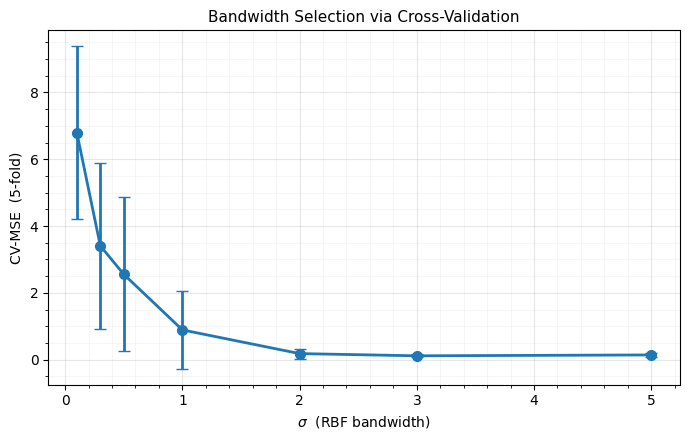

Best sigma = 3.0


In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(
    sigmas,
    cv_scores_sigma,
    yerr=cv_stds_sigma,
    fmt="o-",
    color="C0",
    lw=2,
    markersize=7,
    capsize=4,
)
ax.set_xlabel(r"$\sigma$  (RBF bandwidth)")
ax.set_ylabel("CV-MSE  (5-fold)")
ax.set_title("Bandwidth Selection via Cross-Validation", fontsize=11)
style_ax(ax)
plt.tight_layout()
plt.show()

best_sigma = sigmas[int(np.argmin(cv_scores_sigma))]
print(f"Best sigma = {best_sigma}")

The curve has a clear minimum. Small $\sigma$ overfits (high variance: the kernel matrix is nearly diagonal and the model interpolates noise). Large $\sigma$ underfits (high bias: the kernel smears everything together). The minimum balances these two forces.

### Ridge parameter selection via CV

The ridge parameter $\lambda$ controls the regularization strength in the solution $\alpha = (K + \lambda I)^{-1}y$. Like $\sigma$, it trades bias against variance: too small and the model overfits (small eigenvalues of $K$ are amplified in $\alpha$); too large and useful signal is suppressed.

### Engineering trick: log-scale search for scale parameters

**Engineering trick: log-scale search.** Both $\sigma$ and $\lambda$ span orders of magnitude --- a useful $\lambda$ might be $10^{-4}$ or $10^{0}$, a factor of $10{,}000$ apart. Sampling uniformly between $10^{-4}$ and $1$ puts 99.9% of the budget in $[0.001, 1]$ and almost nothing near $10^{-4}$. Sampling on a *log* scale ($\lambda = 10^u$, $u \sim \text{Uniform}(-4, 0)$) distributes samples evenly per decade, ensuring each order of magnitude gets equal exploration. This is why the $\lambda$ axis below is log-scaled.

In [6]:
lams = [1e-4, 1e-3, 1e-2, 0.1, 1.0]
cv_scores_lam = []
cv_stds_lam = []

for l in lams:
    est = FairKRREstimator(sigma=best_sigma, lam=l, mu=0.0)
    scores = cross_val_score(est, X, y, cv=5, scoring="neg_mean_squared_error")
    cv_scores_lam.append(-scores.mean())
    cv_stds_lam.append(scores.std())
    print(f"lambda = {l:.0e}   CV-MSE = {-scores.mean():.3f} +/- {scores.std():.3f}")

lambda = 1e-04   CV-MSE = 0.132 +/- 0.066
lambda = 1e-03   CV-MSE = 0.107 +/- 0.041
lambda = 1e-02   CV-MSE = 0.115 +/- 0.042


lambda = 1e-01   CV-MSE = 0.244 +/- 0.210


lambda = 1e+00   CV-MSE = 0.580 +/- 0.537


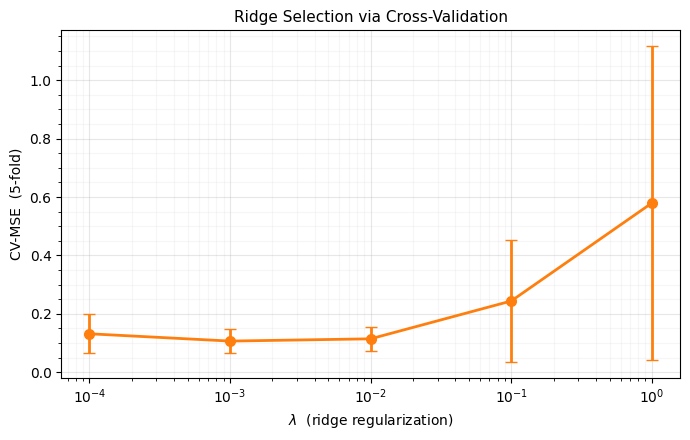

Best lambda = 0.001


In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.errorbar(
    lams,
    cv_scores_lam,
    yerr=cv_stds_lam,
    fmt="o-",
    color="C1",
    lw=2,
    markersize=7,
    capsize=4,
)
ax.set_xscale("log")
ax.set_xlabel(r"$\lambda$  (ridge regularization)")
ax.set_ylabel("CV-MSE  (5-fold)")
ax.set_title("Ridge Selection via Cross-Validation", fontsize=11)
style_ax(ax)
plt.tight_layout()
plt.show()

best_lam = lams[int(np.argmin(cv_scores_lam))]
print(f"Best lambda = {best_lam}")

The log-scale x-axis spreads the candidates evenly. Very small $\lambda$ barely regularizes, so the model overfits; very large $\lambda$ over-regularizes and shrinks the solution toward zero. The optimal $\lambda$ lives somewhere in between.

---
## Fairness-Aware Cross-Validation

### Why `cross_val_score` isn't enough when $q$ exists

When $\mu > 0$, training requires the sensitive attribute $q$. But `cross_val_score` only splits $X$ and $y$ --- it doesn't know about $q$, so it can't pass the correct fold of $q$ to `fit()`.

We also need *two* held-out metrics per fold (MSE *and* CKA), whereas `cross_val_score` returns only one scorer. The solution is a manual K-fold loop.

### Manual K-fold that splits $X$, $y$, and $q$ together

**Engineering trick: $q$ splitting.** sklearn's CV utilities don't know about sensitive attributes. A manual `KFold` loop is needed to index into $X$, $y$, *and* $q$ with the same train/test indices. Forgetting to split $q$ is a subtle bug: the model would train on all of $q$ but be evaluated on a subset of $y$, producing optimistic fairness estimates.

In [8]:
def fair_cv(X, y, q, mu, sigma, lam, sigma_q=1.0, epochs=200, lr=0.005, n_splits=5):
    """K-fold CV returning per-fold MSE and CKA on held-out data.

    Properly splits X, y, and q together to avoid data leakage.
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    mses, ckas = [], []

    for _fold, (train_idx, test_idx) in enumerate(kf.split(X)):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        q_tr, q_te = q[train_idx], q[test_idx]

        model = FairKernelRidge(sigma=sigma, lam=lam, mu=mu, sigma_q=sigma_q)
        model.fit(X_tr, y_tr, q=q_tr, epochs=epochs, lr=lr)
        yh = np.array(model.predict(X_te)).ravel()

        fold_mse = float(np.mean((yh - y_te) ** 2))
        fold_cka = float(cka_rbf(yh.reshape(-1, 1).astype("float32"), q_te))
        mses.append(fold_mse)
        ckas.append(fold_cka)

    return np.array(mses), np.array(ckas)

### Sweeping $\mu$ with held-out fairness metrics

We now sweep $\mu \in \{0, 1, 5, 10, 20\}$ using the best $\sigma$ and $\lambda$ found above. For each $\mu$, we run 5-fold CV and record both the held-out MSE and the held-out CKA.

This gives us *honest* estimates of both accuracy and fairness --- the model has never seen the test fold during training, so it cannot memorize the group structure.

In [9]:
mus = [0, 1, 5, 10, 20]
cv_mse_means, cv_mse_stds = [], []
cv_cka_means, cv_cka_stds = [], []

for mu in mus:
    mses, ckas = fair_cv(
        X, y, q, mu=mu, sigma=best_sigma, lam=best_lam, epochs=200, lr=0.005
    )
    cv_mse_means.append(mses.mean())
    cv_mse_stds.append(mses.std())
    cv_cka_means.append(ckas.mean())
    cv_cka_stds.append(ckas.std())
    print(
        f"mu = {mu:5.1f}   "
        f"CV-MSE = {mses.mean():.3f} +/- {mses.std():.3f}   "
        f"CV-CKA = {ckas.mean():.3f} +/- {ckas.std():.3f}"
    )

mu =   0.0   CV-MSE = 0.110 +/- 0.010   CV-CKA = 0.674 +/- 0.022


mu =   1.0   CV-MSE = 0.131 +/- 0.015   CV-CKA = 0.635 +/- 0.022


mu =   5.0   CV-MSE = 0.828 +/- 0.086   CV-CKA = 0.416 +/- 0.047


mu =  10.0   CV-MSE = 1.792 +/- 0.274   CV-CKA = 0.293 +/- 0.077


mu =  20.0   CV-MSE = 3.694 +/- 0.488   CV-CKA = 0.176 +/- 0.082


---
## Results: Cross-Validated Pareto Frontier

The canonical fairness-accuracy plot now uses **held-out** metrics. Each point represents a different $\mu$ value, and the error bars show the standard deviation across the $K = 5$ folds.

### Error bars quantify stability

**Engineering trick: error bars.** An `errorbar` plot with `capsize` shows per-fold variability. If the error bars are large at some $\mu$, the model is *unstable* at that operating point --- small changes in the training set cause large swings in fairness or accuracy. This information is invisible without cross-validation. Narrow error bars indicate that the trade-off is reliable and will likely transfer to deployment.

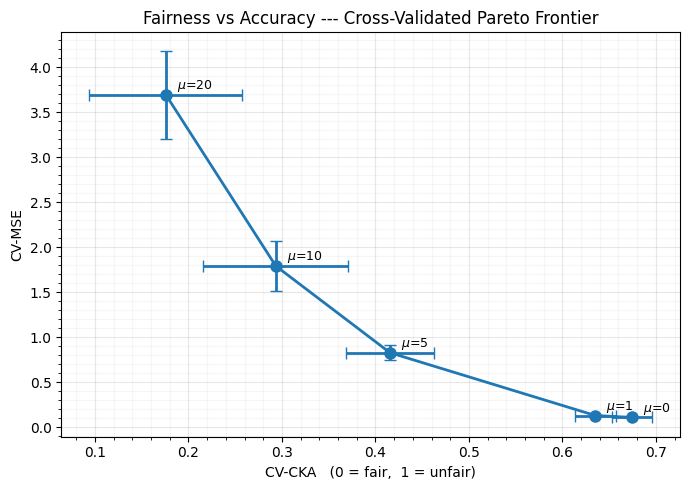

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(
    cv_cka_means,
    cv_mse_means,
    xerr=cv_cka_stds,
    yerr=cv_mse_stds,
    fmt="o-",
    color="C0",
    lw=2,
    markersize=8,
    capsize=4,
)
for i, mu in enumerate(mus):
    ax.annotate(
        f"$\\mu$={mu}",
        (cv_cka_means[i], cv_mse_means[i]),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=9,
    )
ax.set_xlabel("CV-CKA   (0 = fair,  1 = unfair)")
ax.set_ylabel("CV-MSE")
ax.set_title("Fairness vs Accuracy --- Cross-Validated Pareto Frontier", fontsize=12)
style_ax(ax)
plt.tight_layout()
plt.show()

**Reading the plot.** Moving from right to left (decreasing CKA), the model becomes fairer but the MSE rises. The error bars tell us *how much to trust each point*: if the horizontal and vertical bars are small, the trade-off is stable across folds; if they are large, that operating point is sensitive to the particular train/test split and may not generalize.

Compare this to Part 1's Pareto frontier, which used training-set metrics. The cross-validated version typically shows higher MSE and higher CKA (the model looked better on training data than it really was). This gap is the *overfitting correction* that CV provides.

---

## What We Learned

1. **Training-set metrics overstate both accuracy and fairness.**
   Cross-validation is essential for honest model selection.
2. **$\sigma$ and $\lambda$ are tuned on a log scale** because they
   span orders of magnitude. Uniform sampling wastes budget.
3. **The sklearn contract** (`BaseEstimator` + `RegressorMixin`)
   gives `get_params` / `set_params` / `score` for free, enabling    `cross_val_score` with a single wrapper class.
4. **Manual K-fold is needed** when the model requires extra inputs
   ($q$) that sklearn doesn't know about. Always split all arrays    with the same indices.
5. **Error bars on the Pareto frontier** reveal model stability.
   A fair operating point with large error bars is unreliable.

---

**Next**: [Part 3](tutorial_fair_krr_part3.py) explores the full `fairkl` API and Keras integration (losses, metrics, kernel layers).